# NASA randomized and recommissioned battery dataset

An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions:

The dataset repository is organized into three main folders, each containing one group of life cycled battery packs. 
Within each folder individual battery packs own their dedicated csv file for continuous data logging, which are named with their respective battery pack number.

The folders are named: 

- regular_alt_batteries: Containing one csv file for each battery pack cycled at the same load level or load range throughout lifetime
- recommissioned_batteries: Containing one csv file for each battery pack cycled at different load levels at varying life stages
- second_life_batteries: Containing one csv file for each second life battery pack cycled at constant current througout the second life 

The columns in each csv file contain the following data with the provided units: 

The following columns contain data throughout the cycling process: 

- start time: [mm:dd:yyyy hh:mm:ss] (start time of each cycle day for each battery pack, in most cases approximately 24h)
- relative time: [s] (the relative time is continuous from the beginning of the entire life cycle to the failure of each battery pack)
- mode: -1 = discharge, 0 = rest, 1 = charge
- voltage charger: [V] (continuous battery pack voltage measurement right after the connection of the battery pack to the charger board)
- temperature battery: [C] (continuous temperature measurement on the battery cell electrode surface)

Those columns only contain data when the respective battery is connected to the load board and performing a discharge mission

- voltage load: [V] (battery pack voltage measured on the load board)
- current load: [A] (discharge current measured on the load board using current sense resistors)
- temperature mosfet: [C] (temperature on the load board mosfets, measured for safety purposes)
- temperature resistor: [C] (temperature on the load board current sense resistor, measured for safety purposes)
- mission type: 0 = reference discharge (constant current at 2.5A), 1 = regular mission

Please cite this dataset using:

```
@misc{2023_alt_dataset_fricke_et_al,
	Author = {Kajetan Fricke and Renato G. Nascimento and Felipe A. C. Viana},
	Doi = {},
	Howpublished = {},
	Month = {July},
	Publisher = {nasa-data@lists.arc.nasa.gov},
	Title = {An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions},
	Url = {},
	Version = {0.0.1},
	Year = {2023}}
```

The corresponding reference entry should look like: 
An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions, v0.0.1, 

### Publications

The following publications out of the PML-UCF research group used/referred to this repository:
- K. Fricke, R. G. Nascimento, M. Corbetta, C. S. Kulkarni, F. A. C. Viana, "[Prognosis of Li-ion Batteries Under Large Load Variations Using Hybrid Physics-Informed Neural Networks]"
- K. Fricke, R. G. Nascimento, M. Corbetta, C. S. Kulkarni, F. A. C. Viana, "[An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions]"


## Regular accelerated life test (regular alt batteries folder):

This folder contains the data files from battery packs subject to constant and variable loading conditions, 
where the current range of the latter remains the same throughout the battery life.

The assigned battery packs in this folder are numbered as
follows:

– Constant current:
Those battery packs were subjected to the same load level during discharge missions over their respective life time.

The here provided averaged current levels are approximated, and might vary slightly:

* 9.30A: Battery pack 0.1 and 1.1
* 12.9A: Battery pack 3.1 and 2.2
* 14.3A: Battery pack 2.3 and 5.2
* 16.0A: Battery pack 0.0 and 1.0
* 19.0A: Battery pack 2.0, 3.0 and 2.1

– Variable current:

Those battery packs are subjected to variable current within a discharge cycle.
The current level segments are kept constant for either 40, 60 or 80 seconds before switching to another level.
Both, the amplitude and length of each current level segments was randomly selected to create a pool of different random loading discharge missions.

The here provided averaged current levels are approximated, and might vary slightly:

* 14.3A average (12.9A - 16A range): Battery pack 4.1 and 5.1
* 17.0A average (16A - 19A range): Battery pack 4.0 and 5.0


## Recommissioned batteries (recommissioned batteries folder):

This folder contains the data files from battery packs where the constant loading conditions were changed throughout the battery life. 
The assigned battery packs in this folder are numbered as follows:

– Two life stages:
The following batteries were subjected to constant current levels at the first provided amplitudes until reaching an capacity level of approximately 2.2Ah,
and then switched to the second current level until reaching end of life

The here provided averaged current levels are approximated, and might vary slightly:

* 16A, 14.3A: Battery pack 3.2
* 14.3A, 16A: Battery pack 5.3
* 16A, 12.9A: Battery pack 0.2 and 3.3
* 16A, 9.30A: Battery pack 1.2 and 2.4

– Three life stages:
Those batteries were subjected to current level switches at approximately 2.2Ah and 2.0Ah of capacity.
The here provided averaged current levels are approximated, and might vary slightly:

* 16A, 14.3A, 7.5A: Battery pack 0.3
* 16A, 7.5A, 14.3A: Battery pack 2.5


## Second life batteries (second life batteries folder):

This folder contains the data files from battery packs that consist of battery cells survived from previously cycled battery packs. 
The assigned battery packs in this folder are numbered as follows:

– 2nd life battery packs:
The following batteries were subjected to constant current levels at the first provided amplitudes until reaching end of life (EOL).
Survivor cells were then reused and subjected to the second provided current level until reaching EOL

The here provided averaged current levels are approximated, and might vary slightly:

* 16.0A, 9.3A: Battery pack 1.3 (First life battery packs: 0.0 & 1.1)
* 14.3A, 7.5A: Battery pack 3.6 (First life battery packs: 2.3 & 5.2)
* 12.9A, 5.0A: Battery pack 5.4 (First life battery packs: 2.2 & 3.1)

## Zyklenbasierte Visualisierung
* Visualisiert ausgewählte Features
* Mehrere Batterielabels werden farblich gekennzeichnet

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

def display_cycle_based_data(cycle_based_df, feature_x, feature_y, showLegend = False): 
    '''
    Displays cycle based data over EFC for given features
    features: One value or list like values
    '''
    num_features = len(feature_y) 
    fig, axes = plt.subplots(nrows=num_features, figsize=(10,num_features*3), sharex=True)
    for i, feature in enumerate(feature_y):
        if num_features == 1:
            sns.lineplot(data=cycle_based_df, x=feature_x, y=feature, ax=axes, hue='batt_label', legend=showLegend)
        else:
            sns.lineplot(data=cycle_based_df, x=feature_x, y=feature, ax=axes[i], hue='batt_label', legend=showLegend)

    plt.legend()
    plt.tight_layout()
    plt.show()

## Visualisierungen

### Datenimport

In [2]:
import pandas as pd

reg_alt_complete = pd.read_csv("reg_alt_complete.csv")
recommissioned_complete = pd.read_csv("recommissioned_complete.csv")
complete_df = pd.read_csv("data_complete.csv")

### Korrelationsmatrix

<Axes: >

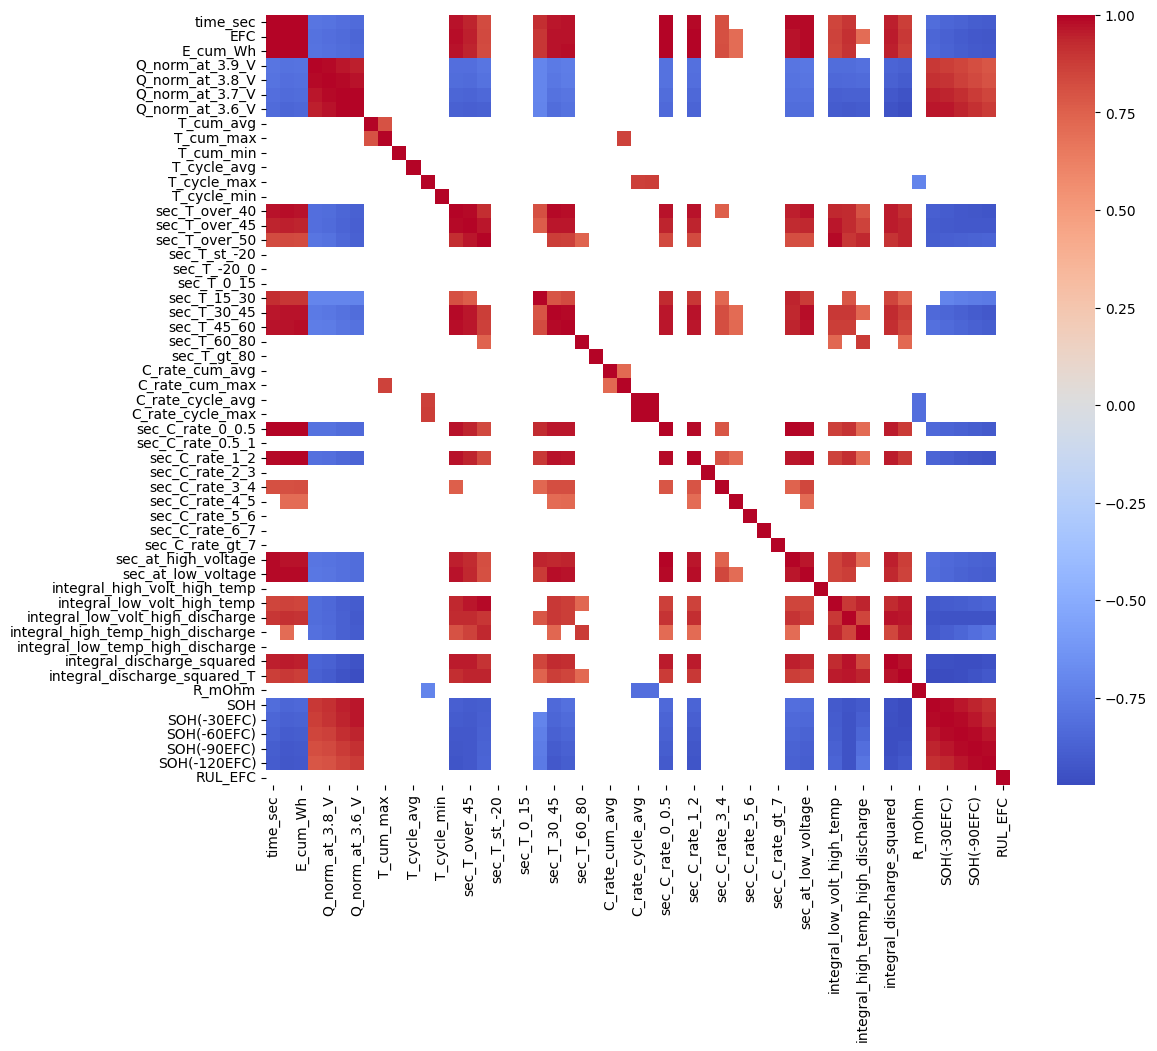

In [3]:
import numpy as np

corr = complete_df.drop(['batt_label','isRefCycle'], axis=1).corr()

mask = (corr.abs() >= 0.7)  # oder 0.6 / 0.8 je nach Strenge
filtered_corr = corr.where(mask)

plt.figure(figsize=(12,10))
sns.heatmap(filtered_corr, cmap='coolwarm', annot=False)

### SOH in Abhängigkeit von verschiedenen Features

C:\Users\Expert\AppData\Local\Temp\ipykernel_13624\2227254737.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


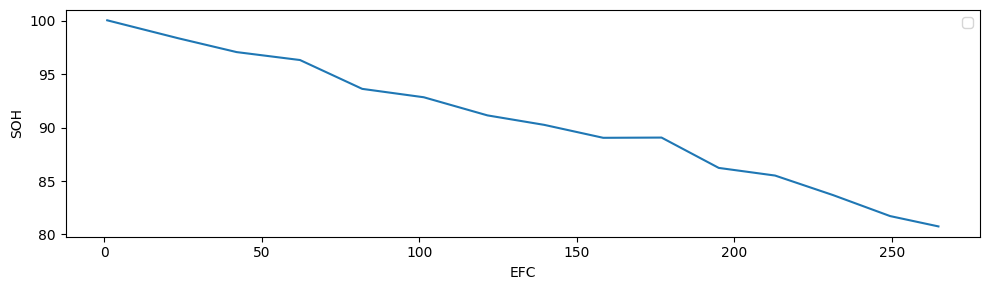

In [6]:
batt_df = complete_df[complete_df['batt_label']=='battery51']
display_cycle_based_data(batt_df, 'EFC', ['SOH'])

C:\Users\Expert\AppData\Local\Temp\ipykernel_13624\2227254737.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


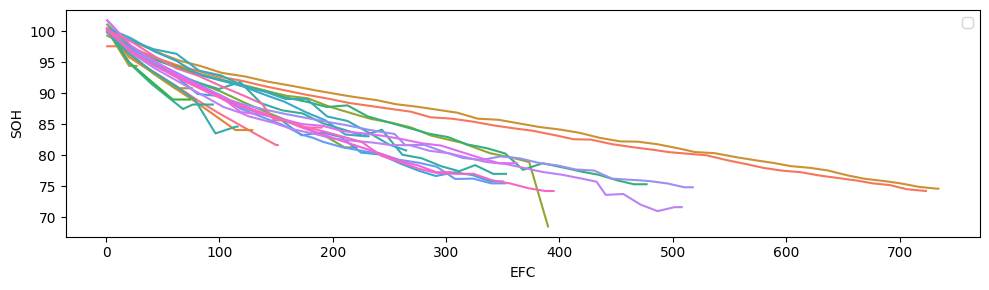

In [4]:
display_cycle_based_data(complete_df, 'EFC', ['SOH'])

C:\Users\Expert\AppData\Local\Temp\ipykernel_13624\2227254737.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


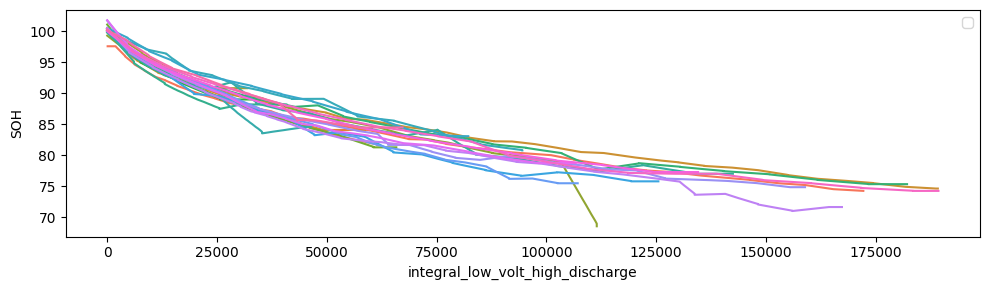

In [5]:
display_cycle_based_data(complete_df, 'integral_low_volt_high_discharge', ['SOH'])